# Tech Challenge Fase 3 — Feature Engineering

Este notebook é a **ponte** entre olhar os dados (notebook 01) e treinar o modelo (notebook 03). Aqui não “melhoramos a nota”: aqui decidimos **o que o modelo pode ver**, **o que ele deve prever** e **como vamos cobrar** essa previsão.

Se você não programa no dia a dia, trate cada seção como uma decisão de pesquisa. O código apenas executa a decisão.

---

## Em uma frase

Transformamos a tabela Silver (município + ano) numa pergunta de sim/não — **“este município já alcançou a meta de alfabetização de 2024?”** — tiramos as colunas que *são* a resposta disfarçada, e separamos **2023 para estudar** e **2024 para a prova**.

---

## O que o notebook 01 já mostrou (e este notebook obedece)

- A linha **não é um aluno**. É a rede municipal de um município em um ano.
- A taxa está em **0 a 100%**, não na escala SAEB (743).
- `taxa_base` copia a taxa (vazamento). `media_portugues` quase copia. Nível da meta é a taxa em degraus.
- Norte e Nordeste estão abaixo; Sul/Sudeste/Centro-Oeste, acima.
- Metade das linhas não tem níveis 0–8 — e depois veremos que isso é **“só 2024 tem”**, não um furo aleatório.

---

## Índice

1. Importações e setup
2. Carregamento (Silver + ano da pasta Hive)
3. Criação do alvo (target)
4. Remoção de vazamento (*data leakage*)
5. Features derivadas
6. Pipeline de pré-processamento (a “receita”, ainda sem aplicar)
7. Divisão treino / teste (backtest 2023→2024)
8. Validação final
9. Salvar (opcional)
10. Resumo


## 1. Importações e setup

Abrimos a classe `DataPreparator`, que concentra as regras deste notebook (ler parquet particionado, criar o alvo, tirar vazamento, etc.). O `reload` evita que o Jupyter use uma versão antiga da classe se você editou o arquivo `.py` no meio da aula.


In [1]:
# Adicionar src ao path e recarregar o módulo (evita kernel com código antigo)
import sys
from pathlib import Path
import importlib

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.preprocessing.data_preparation as data_preparation
importlib.reload(data_preparation)
from src.preprocessing.data_preparation import DataPreparator

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Bibliotecas importadas com sucesso!")
print(f"   DataPreparator em: {data_preparation.__file__}")

✅ Bibliotecas importadas com sucesso!
   DataPreparator em: /Users/vinicius/Documents/workspace/tech_challenge_alfabetizacao/src/preprocessing/data_preparation.py


## 2. Carregamento dos dados

Os arquivos não estão numa pasta “plana”: estão no estilo **Hive** (`.../ano=2023/...parquet`). Cada arquivo é um pedaço (em geral um estado). O `DataPreparator` concatena tudo e **escreve a coluna `ano`** a partir do nome da pasta — no parquet original o ano muitas vezes **não** vem como coluna.

Você deve ver da ordem de **10.896 linhas** e cerca de **45 colunas**, anos **2023 e 2024**. Isso é o censo municipal da rede (código 3), não microdado de aluno.


In [2]:
import importlib
import src.preprocessing.data_preparation as data_preparation
importlib.reload(data_preparation)
from src.preprocessing.data_preparation import DataPreparator

gold_path = '../data/gold'
silver_path = '../data/silver'

preparator = DataPreparator(gold_path=gold_path, silver_path=silver_path)
preparator.load_data()
print('Anos na base:', sorted(preparator.df['ano'].unique()) if 'ano' in preparator.df.columns else 'coluna ano ausente')

📂 Carregando dados de ../data/silver/indicador_alfabetizacao
   Encontrados 49 arquivos particionados em ../data/silver/indicador_alfabetizacao
   ✅ Dataset carregado: 10,896 linhas, 45 colunas
Anos na base: [np.int64(2023), np.int64(2024)]


In [3]:
# Visualizar dados carregados
preparator.df.head()

,id_municipio,taxa_alfabetizacao,media_portugues,fonte,proporcao_aluno_nivel_0,proporcao_aluno_nivel_1,proporcao_aluno_nivel_2,proporcao_aluno_nivel_3,proporcao_aluno_nivel_4,proporcao_aluno_nivel_5,...,meta_nacional_taxa_base,meta_nacional_percentual_participacao,meta_nacional_alfabetizacao_2024,meta_nacional_alfabetizacao_2025,meta_nacional_alfabetizacao_2026,meta_nacional_alfabetizacao_2027,meta_nacional_alfabetizacao_2028,meta_nacional_alfabetizacao_2029,meta_nacional_alfabetizacao_2030,ano
0,2902252,13.11,707.48,batch,3.28,11.48,21.31,34.43,21.31,6.56,...,59.2,87.37,59.9,63.77,67.47,70.97,74.23,77.24,80,2024
1,2919900,12.50,695.94,batch,10.0,20.0,25.0,30.0,2.5,7.5,...,59.2,87.37,59.9,63.77,67.47,70.97,74.23,77.24,80,2024
2,2900207,18.24,709.61,batch,4.4,18.87,16.98,23.9,22.64,8.18,...,59.2,87.37,59.9,63.77,67.47,70.97,74.23,77.24,80,2024
3,2915403,15.25,710.34,batch,0.0,16.95,25.42,23.73,22.03,8.47,...,59.2,87.37,59.9,63.77,67.47,70.97,74.23,77.24,80,2024
4,2933158,17.95,704.38,batch,5.77,19.23,26.92,13.46,19.87,10.26,...,59.2,87.37,59.9,63.77,67.47,70.97,74.23,77.24,80,2024


## 3. Criação da variável alvo (*target*)

O modelo de classificação precisa de um **sim ou não**. Não existe neste Silver “aluno alfabetizado”. A pergunta alinhada à política pública e ao EDA é:

> **A taxa de alfabetização deste município, neste ano, já chegou na meta municipal de 2024?**

- **Classe 1** = sim (na meta ou acima).
- **Classe 0** = não.

**Por que não 743?** 743 é o corte da *escala de proficiência do aluno* no SAEB. Nossa `taxa_alfabetizacao` já é um **percentual de alunos** (0–100). Comparar 62% com 743 não faz sentido.

**Por que a meta de 2024 e não a mediana da taxa?** Porque o desafio é educacional/político: cumprir a meta. A mediana (~62%) seria um exercício estatístico de “acima da metade da turma”. Deixamos essa alternativa só como teste de robustez no 03, se alguém quiser — o alvo oficial deste projeto é a **meta**.

No **conjunto 2023+2024** juntos, cerca de **36%** das linhas são classe 1. Isso **não** é o que o modelo vai ver no treino: depois do corte temporal, 2023 fica com ~18% e 2024 com ~53% (a barra é a de 2024; em 2023 a taxa ainda não tinha chegado lá). A célula abaixo ainda mostra o conjunto todo; o split da seção 7 mostra os dois anos separados.

Linhas sem taxa ou sem meta são **removidas** (~432): não há como rotular sim/não.


In [4]:
# Target municipal: 1 se a taxa atingiu a meta 2024 (não usar 743 — isso é escala SAEB)
preparator.create_target(method='meta')


🎯 Criando variável target (método: meta)
   1 se taxa_alfabetizacao >= meta_municipio_alfabetizacao_2024
   Removidas 432 linhas sem taxa/meta para o target

   📊 Distribuição do target (município na meta / fora da meta):
      Classe 0: 6,747 (64.5%)
      Classe 1: 3,717 (35.5%)


📊 Plotando distribuição do target...
   ✅ Gráfico salvo em reports/figures/target_distribution.png


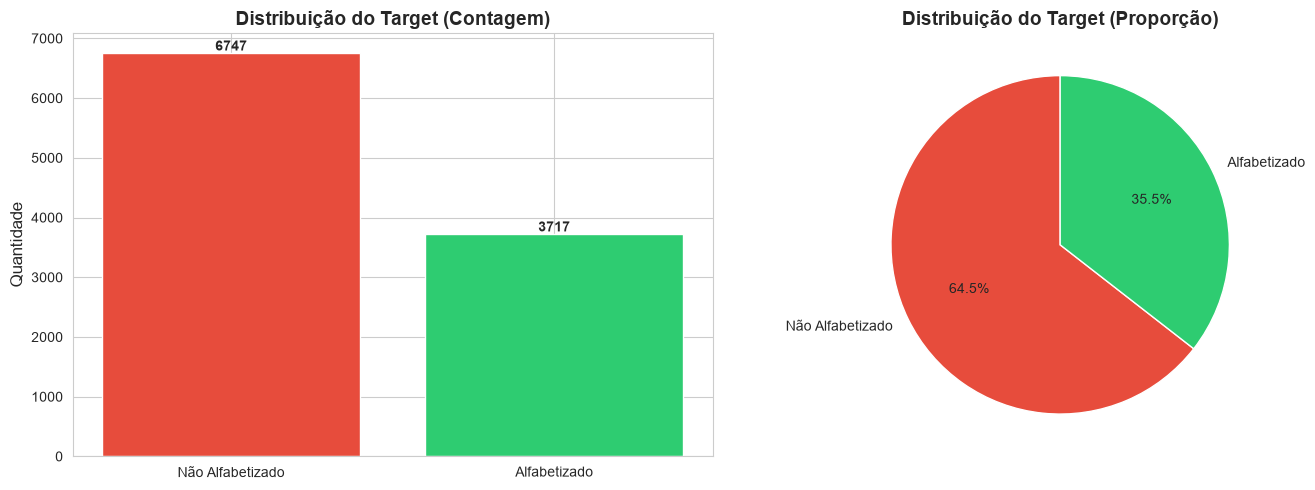

In [5]:
# Visualizar distribuição do target
from src.visualization.plots import DataVisualizer

viz = DataVisualizer(preparator.df)
viz.plot_target_distribution()

### Como ler o gráfico e o print do alvo

O print do conjunto todo (~64% classe 0, ~36% classe 1) é a **mistura dos dois anos**. Não use esse 36% como “o modelo vai ver 36% de positivos”. Depois do split, o treino é bem mais desbalanceado. O gráfico só confirma que as duas classes existem — ninguém está rotulando 100% como 1.


## 4. Remoção de vazamento (*data leakage*)

**Vazamento** = o modelo “prever” usando uma informação que, na vida real, **já é a resposta** ou um recorte dela. A nota fica linda e o modelo não serve para decidir nada.

Analogia: cobrar se a prova foi bem feita olhando o **gabarito** da mesma prova.

O notebook 01 mediu isso com correlação (o quão duas colunas andam juntas; 1,00 = andam idênticas):

| Coluna | Por que sai | Evidência |
|---|---|---|
| `taxa_alfabetizacao` | É o próprio resultado; entra na conta do alvo | — |
| `meta_municipio_taxa_base` | Cópia da taxa | r ≈ 1,00 |
| `media_portugues` | Quase a mesma família SAEB | r ≈ 0,93 |
| `meta_municipio_nivel_alfabetizacao` | A taxa fatiada em faixas | médias em degraus 31% → 89% |

**Podem ficar (por enquanto):** geografia, participação na prova, níveis 0–8 (com ressalva de nulo), a **meta 2024** como número de planejamento.

Atenção que o notebook 03 ainda **revisa** o que pode ficar: as metas municipais 2024–2029, na prática, são interpoladas a partir da taxa (r ≈ 0,97) — mesma família da `taxa_base`. E os níveis 0–8 só existem em 2024. Tirar vazamento é um processo em duas etapas (02 remove o óbvio; 03 remove o que o backtest revela).


In [6]:
# Remover features com leakage
print("Colunas ANTES da remoção:", len(preparator.df.columns))

preparator.remove_leakage_features()

print("\nColunas DEPOIS da remoção:", len(preparator.df.columns))

Colunas ANTES da remoção: 46

⚠️  Removendo features com data leakage...
   ❌ Removidas 4 features:
      - taxa_alfabetizacao
      - media_portugues
      - meta_municipio_taxa_base
      - meta_municipio_nivel_alfabetizacao

Colunas DEPOIS da remoção: 42


## 5. Features derivadas — colunas que o EDA pediu e o Silver não traz prontas

- **`tem_nivel`** — 1 se a linha tem os nove níveis 0–8 preenchidos. O EDA viu 50% de furo; o modelo precisa *saber* que o furo existe. (No 03 descobriremos que no treino 2023 isso vira sempre 0.)
- **`prop_niveis_baixos` / `prop_niveis_altos`** — somar níveis 0–3 e 6–8. Nove colunas que somam ~100% são redundantes (multicolinearidade): o modelo se perde. Duas resumos bastam.
- **`codigo_regiao`** — Norte…Sul em número (1 a 5), além do texto `regiao`.
- **`tem_meta_2024`** — se a meta existe. Depois de dropar quem não tem meta, isso fica sempre 1 — o 03 tira por ser constante.
- **`diff_meta_mun_uf`** — meta do município menos meta do estado (ambição relativa). Também entra na família da trajetória e o 03 pode tirar.

Os níveis no parquet às vezes vêm como **texto**. Sem converter para número, a soma vira concatenação de strings e o pipeline trata porcentagem como categoria (centenas de colunas inúteis). O código converte **antes** de somar.


In [7]:
# Recarrega a classe (o kernel guarda o método antigo se só a célula de features for reexecutada)
import importlib
import src.preprocessing.data_preparation as data_preparation
importlib.reload(data_preparation)
from src.preprocessing.data_preparation import DataPreparator

data_preparation.DataPreparator.create_derived_features(preparator)


🔧 Criando features derivadas...
   ✅ Criadas 6 features derivadas:
      + tem_nivel
      + prop_niveis_baixos
      + prop_niveis_altos
      + diff_meta_mun_uf
      + tem_meta_2024
      + codigo_regiao


In [8]:
# Visualizar novas features
print("🔧 Features derivadas criadas:")
derived_features = getattr(
    preparator,
    'derived_features',
    ['tem_nivel', 'prop_niveis_baixos', 'prop_niveis_altos',
     'codigo_regiao', 'tem_meta_2024', 'diff_meta_mun_uf'],
)

found = False
for feat in derived_features:
    if feat not in preparator.df.columns:
        continue
    found = True
    serie = preparator.df[feat]
    print(f"\n   ✅ {feat}")
    print(f"      Tipo: {serie.dtype}")
    print(f"      Missing: {serie.isnull().sum()}")
    if pd.api.types.is_numeric_dtype(serie):
        print(f"      Média: {serie.mean():.2f}")

if not found:
    print("   ⚠️  Nenhuma das features derivadas está no DataFrame. Rode a célula anterior.")

🔧 Features derivadas criadas:

   ✅ tem_nivel
      Tipo: int64
      Missing: 0
      Média: 0.50

   ✅ prop_niveis_baixos
      Tipo: float64
      Missing: 5232
      Média: 24.66

   ✅ prop_niveis_altos
      Tipo: float64
      Missing: 5232
      Média: 32.93

   ✅ diff_meta_mun_uf
      Tipo: float64
      Missing: 0
      Média: 2.05

   ✅ tem_meta_2024
      Tipo: int64
      Missing: 0
      Média: 1.00

   ✅ codigo_regiao
      Tipo: int64
      Missing: 0
      Média: 3.23


## 6. Pipeline de pré-processamento — a receita, ainda crua

Modelos de scikit-learn não gostam de buraco nem de texto cru (“Nordeste”). O *pipeline* é a **receita padronizada**:

- **Números:** preencher nulos com a **mediana** (o valor do meio; robusto a extremos) e colocar tudo na mesma escala (*StandardScaler* — média 0, dispersão 1), para a logística não achar que “participação 80” pesa 80 vezes mais que “código de região 4”.
- **Texto (UF, região):** nulos viram a palavra `missing`; cada valor vira uma coluna 0/1 (*one-hot*).

**Por que criar a receita *antes* do split e só **usar** depois?** A mediana e a escala têm que ser calculadas **só no treino**. Se você calcular a mediana com 2024 junto, um pouquinho do futuro vaza para o tradutor. Nesta etapa nós **montamos** o objeto; o *fit* (aprender mediana/escala) acontece no notebook 03, **dentro** de cada fold de 2023.

Os ~57 mil nulos que você pode ver em `X_train` mais tarde são, sobretudo, níveis vazios. Isso é esperado. Quem imputa é o pipeline, não uma edição manual da tabela.


In [9]:
# Criar pipeline
preparator.prepare_features()


🔨 Preparando pipeline de pré-processamento...

   📊 Features identificadas:
      Numéricas (41): ['proporcao_aluno_nivel_0', 'proporcao_aluno_nivel_1', 'proporcao_aluno_nivel_2', 'proporcao_aluno_nivel_3', 'proporcao_aluno_nivel_4']...
      Categóricas (2): ['nome_uf', 'regiao']
   ⚠️  Features constantes (não informam o modelo): ['meta_municipio_alfabetizacao_2030', 'meta_uf_alfabetizacao_2030', 'meta_nacional_alfabetizacao_2024', 'meta_nacional_alfabetizacao_2025', 'meta_nacional_alfabetizacao_2026', 'meta_nacional_alfabetizacao_2027', 'meta_nacional_alfabetizacao_2028', 'meta_nacional_alfabetizacao_2029', 'meta_nacional_alfabetizacao_2030', 'tem_meta_2024']
   ✅ Pipeline criado com sucesso!


## 7. Divisão treino / teste (backtest) — versão para qualquer leitor

**Backtest** = treinar no passado e cobrar no futuro. É o teste mais parecido com “será que em 2024 o município cumpre a meta?”, usando só o que 2023 permitiria saber **sem** o resultado de 2024.

### Os três papéis (a aula) neste dado concreto

| Palavra da aula | Neste projeto | Pode usar para escolher o modelo? |
|---|---|---|
| Treino | Todas as linhas de **2023** | Sim |
| Validação | Vários recortes **de 2023** (CV no notebook 03) | Sim |
| Teste | Todas as linhas de **2024** | **Não** — uma vez, no fim |

Não criamos uma pasta física “validação”. A validação *é* a média das provas internas de 2023. O 2024 não entra nessa média.

O mesmo município em 2023 e 2024 **pode** (e deve) aparecer nos dois lados: estamos prevendo o **ano seguinte da mesma cidade**, não um aluno novo. O que seria trapaça: sortear as **linhas** e deixar 2024 no treino e 2023 no teste, ou as duas no treino.

### Por que as classes mudam (18% vs 53%)

A barra é a **meta de 2024**. Em 2023 a taxa média (~60,5%) ainda estava abaixo (~62,2%). Em 2024 a taxa média (~63,3%) já tinha passado. Por isso classe 1: ~18% no treino, ~53% no teste. Métrica principal no 03: **F1** (e, no teste, balanced accuracy).

### O que recusamos, em português

- **80/20 aleatório por linha:** o mesmo município vaza; passado e futuro se misturam; a nota fica otimista.
- **Três fatias 60/20/20 aleatórias:** a aula não pediu um sorteio; pediu papéis. Três fatias repetem o erro acima.
- **Treinar em 2024 e testar em 2023:** prever o passado.
- **Olhar 2024 para escolher profundidade de árvore:** o vestibular vira gabarito.

Os itens 7.1–7.4 abaixo são a mesma regra, com o vocabulário da aula (CV, GroupKFold, leakage).

### 7.1 O que fazemos

| Papel | Onde | Para quê | Pode usar para escolher hiperparâmetro? |
|---|---|---|---|
| **Treino** | Ano **2023** (inteiro) | Ajustar o modelo | Sim (é o aprendizado) |
| **Validação** | **CV no treino 2023** (notebook 03) | Escolher modelo e Grid Search | Sim |
| **Teste** | Ano **2024** | Nota final | **Não** — uma vez, depois de escolher o modelo |

- Materializamos `ano` a partir da partição Hive (`ano=2023` / `ano=2024`).
- `ano`, `id_municipio`, `nome_municipio` e `fonte` **não** entram como feature. `ano` só corta o tempo. `groups_train` (`id_municipio` do 2023) vai para o `GroupKFold` no notebook 03.

O mesmo município **pode** aparecer em 2023 e em 2024: isso é o backtest (prever o futuro da mesma unidade). O que não pode é misturar os dois anos no mesmo sorteio.

O target é `taxa_alfabetizacao >= meta_municipio_alfabetizacao_2024`. Em 2023 essa barra é mais dura (~18% classe 1) do que em 2024 (~53%). Isso é o recorte temporal, não um erro do split. Métrica principal no 03: **F1** (classes desbalanceadas no treino).

### 7.2 O que é “Validação = CV no treino”

Não criamos uma pasta física de validação. O 2023 é dividido em *k* folds (ex.: 5):

1. Treina em 4/5 do 2023
2. Avalia no 1/5 que ficou de fora
3. Repete até cada pedaço ter sido validação uma vez
4. O Grid Search fica com a **média** dessas notas

Isso **é** a validação. O 2024 não entra nessa média.

**Grid Search + CV no treino:** o `GridSearchCV` (notebook 03) testa combinações de hiperparâmetros só com essa média de CV. Só o vencedor é aplicado no 2024.

**GroupKFold por `id_municipio`:** um município não fica ao mesmo tempo no fold de treino e no de validação. No 2023 há em geral **uma linha por município**, então GroupKFold ≈ KFold; o grupo existe para o protocolo ficar correto se no futuro houver mais de uma linha por município no treino.

### 7.3 O que não fazemos (e por quê)

**Não** `train_test_split` 80/20 estratificado **por linha**

- Quase todo município tem duas linhas (2023 e 2024). O sorteio pode colocar 2023 no treino e 2024 no teste *ou o contrário*, e ainda pior: as duas no treino.
- Features do mesmo município nos dois anos são parecidas → métrica otimista (**leakage**).
- Mistura passado e futuro → **não é backtest**.

**Não** tunar hiperparâmetro olhando o teste 2024

- O 2024 deixaria de ser teste e viraria validação disfarçada.
- A nota do relatório não mediria generalização, só o quanto você encaixou o 2024.
- Regra: escolheu `max_depth`, modelo, limiar? Foi com CV no **2023**. O 2024 só na avaliação final (notebooks 03/04).

**Não** três splits aleatórios (60/20/20) “treino / validação / teste”

- A aula descreve **papéis**, não um sorteio em três pedaços.
- Três fatias aleatórias repetem o erro do 80/20: leakage de município e mistura de anos.
- Aqui o **tempo** já separa treino (2023) e teste (2024). A validação é a CV **dentro** do 2023. Um holdout aleatório extra de 2023 só desperdiça dado.

**Não** treinar em 2024 e testar em 2023

- Backtest invertido: o modelo “prevê o passado”.

### 7.4 Sequência até o notebook 04

1. **Este notebook:** corta 2023 / 2024 e guarda `groups_train`.
2. **Notebook 03:** Grid Search + `GroupKFold` **só no 2023**; escolhe o modelo (F1).
3. **Notebook 04:** o modelo escolhido no **2024**, uma vez.

Frase para o relatório: *Unidade município-ano. Target: taxa ≥ meta 2024. Split temporal 2023→2024 (backtest). Hiperparâmetros via CV agrupada no treino. Teste 2024 só na avaliação final.*


In [10]:
import importlib
import src.preprocessing.data_preparation as data_preparation
importlib.reload(data_preparation)
from src.preprocessing.data_preparation import DataPreparator

# Backtest: treino 2023, teste 2024 (não é 80/20 aleatório)
data_preparation.DataPreparator.split_data(preparator, strategy='temporal')


✂️  Backtest temporal: treino 2023 / teste 2024
   Validação = CV no treino (notebook 03). Teste não entra no tuning.
   Municípios em treino e teste (esperado no backtest): 5,232
   ✅ Divisão concluída:
      Treino: 5,232 amostras
      Teste:  5,232 amostras

   📊 Distribuição do target:
      Treino - Classe 0: 82.2% | Classe 1: 17.8%
      Teste  - Classe 0: 46.7% | Classe 1: 53.3%


### Como ler o print do split

Você deve ver:

- “Backtest temporal: treino 2023 / teste 2024”
- Municípios em treino **e** teste: **5.232** (é o mesmo conjunto de cidades nos dois anos — correto)
- Treino 5.232 / teste 5.232
- Treino classe 1 ≈ **17,8%** | teste classe 1 ≈ **53,3%**

Se as classes saíssem ~36% nos dois lados, alguém sorteou linhas em vez de cortar o ano. Se o teste tivesse 2023, o tempo está invertido.


## 8. Validação final — checklist antes do notebook 03

Antes de treinar, a célula abaixo deve mostrar:

- **5.232** linhas no treino e **5.232** no teste (um município × um ano de cada lado, na prática).
- Mesmas **colunas** em `X_train` e `X_test` (o número de linhas iguais nas classes **não** é exigido).
- `groups_train` com 5.232 municípios — vai para o `GroupKFold`.
- Nenhuma coluna `ano`, `id_municipio`, `taxa_alfabetizacao`, `media_portugues` em `X`.
- Nulos ainda presentes nos níveis: **ok**. Quem preenche é o pipeline no 03.

Distribuição ~82/18 no treino e ~47/53 no teste: **esperado**, não um split quebrado.


In [11]:
X_train, X_test, y_train, y_test, preprocessor = preparator.get_data()

print("VALIDAÇÃO DOS DADOS PREPARADOS")
print("=" * 80)
print(f"\nShapes:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test:  {y_test.shape}")

if getattr(preparator, 'groups_train', None) is not None:
    print(f"\nGrupos (municípios) no treino para GroupKFold: {preparator.groups_train.nunique():,}")

print(f"\nDistribuição do target:")
print("   Treino:")
print(y_train.value_counts(normalize=True).round(3))
print("\n   Teste:")
print(y_test.value_counts(normalize=True).round(3))

leak_cols = [c for c in ['ano', 'id_municipio', 'taxa_alfabetizacao', 'media_portugues'] if c in X_train.columns]
print(f"\nColunas que não deveriam estar em X: {leak_cols or 'nenhuma'}")
print(f"Valores faltantes em X_train: {X_train.isnull().sum().sum():,}")
print("\n" + "=" * 80)
print("Dados prontos para o notebook 03 (CV no treino, teste 2024 no final).")

VALIDAÇÃO DOS DADOS PREPARADOS

Shapes:
   X_train: (5232, 43)
   X_test:  (5232, 43)
   y_train: (5232,)
   y_test:  (5232,)

Grupos (municípios) no treino para GroupKFold: 5,232

Distribuição do target:
   Treino:
target
0    0.822
1    0.178
Name: proportion, dtype: float64

   Teste:
target
1    0.533
0    0.467
Name: proportion, dtype: float64

Colunas que não deveriam estar em X: nenhuma
Valores faltantes em X_train: 57,552

Dados prontos para o notebook 03 (CV no treino, teste 2024 no final).


## 9. Salvar dados preparados

Grava `X`/`y` de treino e teste, o preprocessor e os grupos dos municípios. O notebook 03 prefere ler daqui. Se você mudar o alvo ou o split, **apague ou recubra** esses arquivos — senão o 03 treina uma versão velha.


In [12]:
import joblib
from pathlib import Path

# Criar diretório
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

# Salvar splits
X_train.to_parquet(processed_dir / 'X_train.parquet')
X_test.to_parquet(processed_dir / 'X_test.parquet')
y_train.to_frame('target').to_parquet(processed_dir / 'y_train.parquet')
y_test.to_frame('target').to_parquet(processed_dir / 'y_test.parquet')

# Salvar preprocessor e grupos do treino (GroupKFold no notebook 03)
joblib.dump(preprocessor, processed_dir / 'preprocessor.pkl')
if getattr(preparator, 'groups_train', None) is not None:
    preparator.groups_train.to_frame('id_municipio').to_parquet(
        processed_dir / 'groups_train.parquet'
    )

print("💾 Dados preparados salvos em data/processed/")

💾 Dados preparados salvos em data/processed/


## 10. Resumo — o que levar para o notebook 03 e para o relatório

1. **Dado:** Silver `indicador_alfabetizacao`, coluna `ano` lida da pasta.
2. **Pergunta:** município-ano já atingiu a meta **de 2024**? (não: “aluno passou de 743”).
3. **Vazamento óbvio fora:** taxa, média de português, taxa base, nível da meta.
4. **Derivadas:** `tem_nivel`, resumo de níveis, região numérica, flags de meta.
5. **Cobrança:** estudar 2023, validar *dentro* de 2023, prova em 2024. Sem 80/20.
6. **Classes diferentes nos dois anos** porque a barra é a de 2024 — isso entra no relatório, não se “conserta” sorteando de novo.

**O 03 ainda fará** (não é esquecimento deste notebook): tirar níveis 0–8 (inexistentes em 2023) e a trajetória de metas municipais (r ≈ 0,97 com a taxa). Feature engineering continua até o modelo honesto.

**Próximo passo:** Notebook 03 — Dummy + logística + florestas, F1 na CV de 2023, uma nota em 2024.
